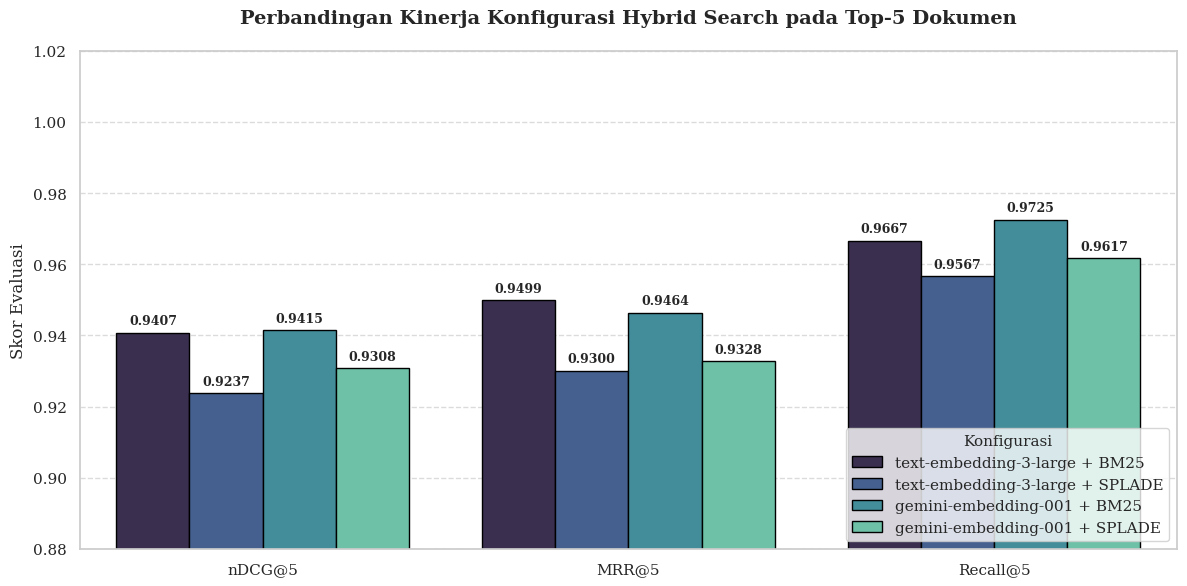

Tabel Data Evaluasi Hybrid Search:


,Konfigurasi,nDCG@5,MRR@5,Recall@5
0,text-embedding-3-large + BM25,0.9407,0.9499,0.9667
1,text-embedding-3-large + SPLADE,0.9237,0.9300,0.9567
2,gemini-embedding-001 + BM25,0.9415,0.9464,0.9725
3,gemini-embedding-001 + SPLADE,0.9308,0.9328,0.9617


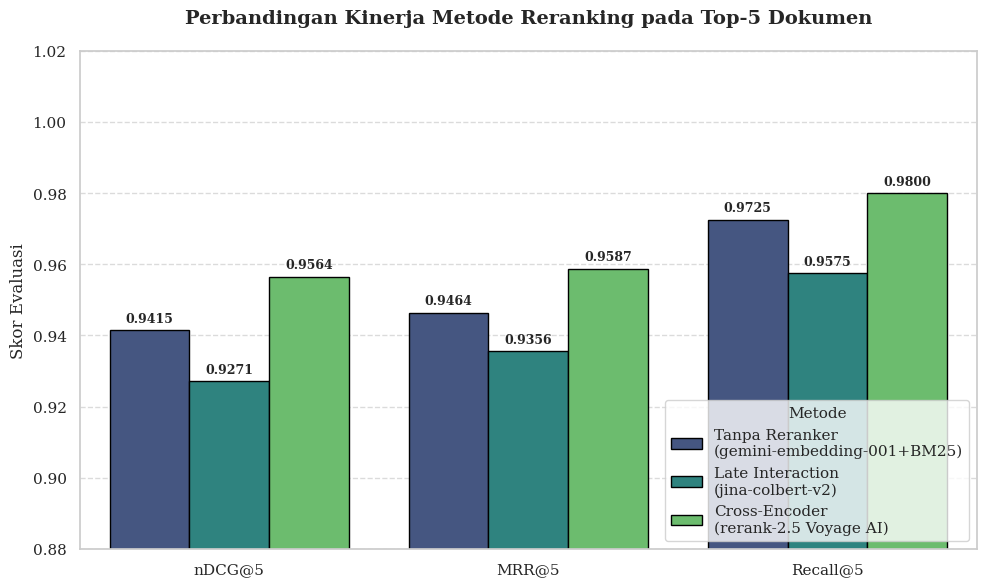

Tabel Data Evaluasi Reranker:


,Metode,nDCG@5,MRR@5,Recall@5
0,Tanpa Reranker\n(gemini-embedding-001+BM25),0.9415,0.9464,0.9725
1,Late Interaction\n(jina-colbert-v2),0.9271,0.9356,0.9575
2,Cross-Encoder\n(rerank-2.5 Voyage AI),0.9564,0.9587,0.9800


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import pickle

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

# Load real evaluation results
with open('data/evaluation_results.pkl', 'rb') as f:
    eval_data = pickle.load(f)

results = eval_data['unified_results']

# ==========================================
# BAGIAN 1: INPUT DATA
# ==========================================

# Data Tahap 1: Seleksi Hybrid Search (Retrieval)
data_retrieval = {
    'Konfigurasi': [
        'text-embedding-3-large + BM25',
        'text-embedding-3-large + SPLADE',
        'gemini-embedding-001 + BM25',
        'gemini-embedding-001 + SPLADE'
    ],
    'nDCG@5': [
        results['hybrid_openai_bm25']['ndcg@5'],
        results['hybrid_openai_splade']['ndcg@5'],
        results['hybrid_gemini_bm25']['ndcg@5'],
        results['hybrid_gemini_splade']['ndcg@5'],
    ],
    'MRR@5': [
        results['hybrid_openai_bm25']['mrr@5'],
        results['hybrid_openai_splade']['mrr@5'],
        results['hybrid_gemini_bm25']['mrr@5'],
        results['hybrid_gemini_splade']['mrr@5'],
    ],
    'Recall@5': [
        results['hybrid_openai_bm25']['recall@5'],
        results['hybrid_openai_splade']['recall@5'],
        results['hybrid_gemini_bm25']['recall@5'],
        results['hybrid_gemini_splade']['recall@5'],
    ]
}

# Data Tahap 2: Evaluasi Reranker (base: gemini-embedding-001 + BM25)
data_rerank = {
    'Metode': [
        'Tanpa Reranker\n(gemini-embedding-001+BM25)',
        'Late Interaction\n(jina-colbert-v2)',
        'Cross-Encoder\n(rerank-2.5 Voyage AI)'
    ],
    'nDCG@5': [
        results['hybrid_gemini_bm25']['ndcg@5'],
        results['hybrid_gemini_bm25_colbert']['ndcg@5'],
        results['voyageai_rerank2.5']['ndcg@5'],
    ],
    'MRR@5': [
        results['hybrid_gemini_bm25']['mrr@5'],
        results['hybrid_gemini_bm25_colbert']['mrr@5'],
        results['voyageai_rerank2.5']['mrr@5'],
    ],
    'Recall@5': [
        results['hybrid_gemini_bm25']['recall@5'],
        results['hybrid_gemini_bm25_colbert']['recall@5'],
        results['voyageai_rerank2.5']['recall@5'],
    ]
}

df_retrieval = pd.DataFrame(data_retrieval)
df_rerank = pd.DataFrame(data_rerank)

df_retrieval_melted = df_retrieval.melt(id_vars="Konfigurasi", var_name="Metrik", value_name="Skor")
df_rerank_melted = df_rerank.melt(id_vars="Metode", var_name="Metrik", value_name="Skor")

# ==========================================
# BAGIAN 2: VISUALISASI PERBANDINGAN RETRIEVAL
# ==========================================

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_retrieval_melted,
    x="Metrik",
    y="Skor",
    hue="Konfigurasi",
    palette="mako",
    edgecolor="black",
    linewidth=1
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=4, fontsize=9, fontweight='bold')

plt.title('Perbandingan Kinerja Konfigurasi Hybrid Search pada Top-5 Dokumen', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('')
plt.ylabel('Skor Evaluasi', fontsize=12)
plt.ylim(bottom=0.88, top=1.02)
plt.legend(title='Konfigurasi', title_fontsize=11, loc='lower right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('perbandingan_retrieval.png', dpi=300, bbox_inches='tight')
plt.show()

print("Tabel Data Evaluasi Hybrid Search:")
display(df_retrieval.round(4))

# ==========================================
# BAGIAN 3: VISUALISASI PERBANDINGAN RERANKER
# ==========================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_rerank_melted,
    x="Metrik",
    y="Skor",
    hue="Metode",
    palette="viridis",
    edgecolor="black",
    linewidth=1
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=4, fontsize=9, fontweight='bold')

plt.title('Perbandingan Kinerja Metode Reranking pada Top-5 Dokumen', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('')
plt.ylabel('Skor Evaluasi', fontsize=12)
plt.ylim(bottom=0.88, top=1.02)
plt.legend(title='Metode', title_fontsize=11, loc='lower right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('perbandingan_reranker.png', dpi=300, bbox_inches='tight')
plt.show()

print("Tabel Data Evaluasi Reranker:")
display(df_rerank.round(4))


In [8]:
print("Tabel Data Evaluasi Hybrid Search:")
print(df_retrieval.round(4))


Tabel Data Evaluasi Hybrid Search:
                       Konfigurasi  nDCG@5   MRR@5  Recall@5
0    text-embedding-3-large + BM25  0.9407  0.9499    0.9667
1  text-embedding-3-large + SPLADE  0.9237  0.9300    0.9567
2      gemini-embedding-001 + BM25  0.9415  0.9464    0.9725
3    gemini-embedding-001 + SPLADE  0.9308  0.9328    0.9617


In [9]:
print("Tabel Data Evaluasi Reranker:")
print(df_rerank.round(4))


Tabel Data Evaluasi Reranker:
                                        Metode  nDCG@5   MRR@5  Recall@5
0  Tanpa Reranker\n(gemini-embedding-001+BM25)  0.9415  0.9464    0.9725
1          Late Interaction\n(jina-colbert-v2)  0.9271  0.9356    0.9575
2        Cross-Encoder\n(rerank-2.5 Voyage AI)  0.9564  0.9587    0.9800
